# Лабораторная работа №1: Первичное исследование данных

## 1. Постановка задачи

### Описание датасета
Набор данных содержит информацию о транзакциях, клиентах и товарах, включая демографические признаки и финансовые показатели. Эти данные позволяют анализировать покупательское поведение и финансовые итоги каждой сделки.

### Условный заказчик
Коммерческий директор, отдел маркетинга и команда по закупкам розничной сети для анализа поведения покупателей, оптимизации ассортимента и повышения эффективности продаж.

### Возможные задачи ИАД
1. Прогнозирование спроса
2. Сегментация клиентов по покупательскому поведению
3. Анализ ассоциативных правил для оптимизации ассортимента и кросс-продаж

## 2. Паспорт датасета

### Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/retail_sales_dataset.csv')  # Путь к файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 1000 строк, 9 столбцов


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Структура данных

In [2]:
# Информация о столбцах и типах
df.info()

# Статистика по числовым признакам
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### Предположительный смысл
1. Transaction ID: Уникальный идентификатор для каждой транзакции, позволяющий отслеживать и ссылаться на него.
2. Date: Дата совершения транзакции позволяет получить представление о тенденциях продаж с течением времени.
3. Customer ID: Уникальный идентификатор для каждого клиента, позволяющий проводить анализ, ориентированный на клиента.
4. Gender: Пол покупателя (мужчина/женщина), позволяющий получить представление о моделях покупок, основанных на гендерном факторе.
5. Age: Возраст клиента, облегчающий сегментацию и изучение возрастных факторов.
6. Product Category: Категория приобретаемого товара (например, электроника, одежда, косметика), помогающая понять предпочтения в отношении товара.
7. Quantity: Количество приобретенных единиц товара, позволяющее получить представление об объемах закупок.
8. Price per Unit: Цена одной единицы продукта, помогающая в расчетах, связанных с общими расходами.
9. Total Amount: Общая денежная стоимость сделки, демонстрирующая финансовые последствия каждой покупки.

## 3. Аудит качества данных

### 3.1. Пропуски

In [3]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

missing[missing['Пропуски'] > 0]

,Пропуски,Доля (%)


### Краткий вывод:
Данные полностью заполнены. Нет пропущенных значений ни в одном столбце.

### 3.2. Дубликаты

In [4]:
# Проверка полных дубликатов строк
duplicates = df.duplicated().sum()
print(f'Полных дубликатов строк: {duplicates}')

# Проверка дубликатов по ключевому полю (идентификатору транзакции)
id_column = 'Transaction ID'

if id_column in df.columns:
    duplicates_by_id = df.duplicated(subset=[id_column]).sum()
    print(f'Дубликатов по {id_column}: {duplicates_by_id}')

# Проверка дубликатов по ключевому полю (идентификатору клиента)
id_column1 = 'Customer ID'

if id_column1 in df.columns:
    duplicates_by_id = df.duplicated(subset=[id_column1]).sum()
    print(f'Дубликатов по {id_column1}: {duplicates_by_id}')

Полных дубликатов строк: 0
Дубликатов по Transaction ID: 0
Дубликатов по Customer ID: 0


### 3.3. Типические проблемы значений

In [5]:
# Проверка числовых признаков
numeric_features = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
numeric_results = []

for col in numeric_features:
    if col in df.columns:
        result = {
            'Признак': col,
            'Минимум': df[col].min(),
            'Максимум': df[col].max(),
            'Среднее': df[col].mean(),
            'Стандартное отклонение': df[col].std()
        }

        # Специфические проверки для каждого признака
        if col == 'Age':
            # Возраст не может быть отрицательным и обычно не превышает 120 лет
            impossible = (df[col] < 0) | (df[col] > 120)
            suspicious = (df[col] > 100)  # Очень пожилые покупатели
            result['Невозможные (<0 или >120)'] = impossible.sum()
            result['Подозрительные (>100)'] = suspicious.sum()

        elif col == 'Quantity':
            # Количество не может быть отрицательным
            impossible = df[col] < 0
            suspicious = df[col] == 0  # Покупки с нулевым количеством
            result['Невозможные (<0)'] = impossible.sum()
            result['Подозрительные (=0)'] = suspicious.sum()

        elif col == 'Price per Unit':
            # Цена не может быть отрицательной
            impossible = df[col] < 0
            suspicious = df[col] == 0  # Бесплатные товары
            result['Невозможные (<0)'] = impossible.sum()
            result['Подозрительные (=0)'] = suspicious.sum()

        elif col == 'Total Amount':
            # Сумма не может быть отрицательной
            impossible = df[col] < 0
            suspicious = df[col] == 0  # Транзакции на 0
            result['Невозможные (<0)'] = impossible.sum()
            result['Подозрительные (=0)'] = suspicious.sum()

        numeric_results.append(result)

# Проверка ID и дат
print("\n=== ИДЕНТИФИКАТОРЫ И ДАТЫ ===")

if 'Transaction ID' in df.columns:
    print(f"Transaction ID: {df['Transaction ID'].nunique()} уникальных значений")

if 'Customer ID' in df.columns:
    print(f"Customer ID: {df['Customer ID'].nunique()} уникальных клиентов")

if 'Date' in df.columns:
    print(f"Date: тип данных - {df['Date'].dtype}")
    try:
        dates = pd.to_datetime(df['Date'], errors='coerce')
        if dates.notna().any():
            print(f"Диапазон дат: от {dates.min()} до {dates.max()}")
    except:
        print("Формат даты требует проверки")

# Проверка категориальных признаков
categorical_features = ['Gender', 'Product Category']
categorical_results = []

for col in categorical_features:
    if col in df.columns:
        # Проверка "грязных" категорий
        if df[col].dtype == 'object':
            normalized = df[col].astype(str).str.lower().str.strip()
            has_dirty = 'Да' if df[col].nunique() != normalized.nunique() else 'Нет'
        else:
            has_dirty = 'Н/Д'

        categorical_results.append({
            'Признак': col,
            'Уникальных значений': df[col].nunique(),
            '«Грязные» категории': has_dirty
        })

# Вывод результатов
print("\n=== ЧИСЛОВЫЕ ПРИЗНАКИ ===")
for result in numeric_results:
    print(f"\n{result['Признак']}:")
    print(f"  Минимум: {result['Минимум']:.2f}")
    print(f"  Максимум: {result['Максимум']:.2f}")
    print(f"  Среднее: {result['Среднее']:.2f}")
    print(f"  Стандартное отклонение: {result['Стандартное отклонение']:.2f}")

print("\n ПРОВЕРКА АНОМАЛИЙ:")
all_ok = True
for result in numeric_results:
    has_issues = False

    for key in result:
        if ('Невозможные' in key or 'Подозрительные' in key) and result[key] > 0:
            if not has_issues:
                print(f"\n{result['Признак']}:")
                has_issues = True
                all_ok = False
            print(f"   {key}: {result[key]}")

if all_ok:
    print("\n✓ Аномалий не обнаружено")

print("\n=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===")
if categorical_results:
    print(pd.DataFrame(categorical_results).to_string(index=False))

print("\n=== ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ===")
if 'Gender' in df.columns:
    print("\nРаспределение по полу:")
    print(df['Gender'].value_counts())

if 'Product Category' in df.columns and df['Product Category'].nunique() <= 10:
    print("\nТоп категорий товаров:")
    top_categories = df['Product Category'].value_counts().head(5)
    for category, count in top_categories.items():
        print(f"  {category}: {count}")


=== ИДЕНТИФИКАТОРЫ И ДАТЫ ===
Transaction ID: 1000 уникальных значений
Customer ID: 1000 уникальных клиентов
Date: тип данных - str
Диапазон дат: от 2023-01-01 00:00:00 до 2024-01-01 00:00:00

=== ЧИСЛОВЫЕ ПРИЗНАКИ ===

Age:
  Минимум: 18.00
  Максимум: 64.00
  Среднее: 41.39
  Стандартное отклонение: 13.68

Quantity:
  Минимум: 1.00
  Максимум: 4.00
  Среднее: 2.51
  Стандартное отклонение: 1.13

Price per Unit:
  Минимум: 25.00
  Максимум: 500.00
  Среднее: 179.89
  Стандартное отклонение: 189.68

Total Amount:
  Минимум: 25.00
  Максимум: 2000.00
  Среднее: 456.00
  Стандартное отклонение: 560.00

 ПРОВЕРКА АНОМАЛИЙ:

✓ Аномалий не обнаружено

=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===
         Признак  Уникальных значений «Грязные» категории
          Gender                    2                 Н/Д
Product Category                    3                 Н/Д

=== ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ===

Распределение по полу:
Gender
Female    510
Male      490
Name: count, dtype: int64

Топ категорий тов

### 3.4. Выбросы

Выбросов по методу IQR: 0


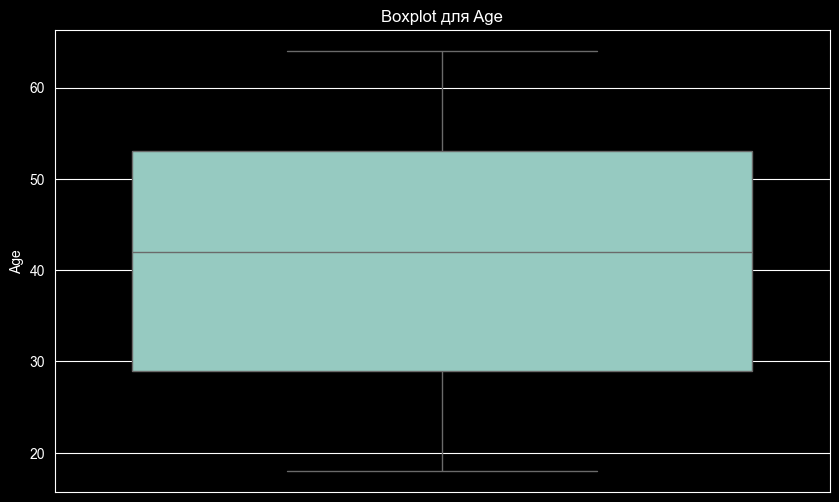

Выбросов по методу IQR: 0


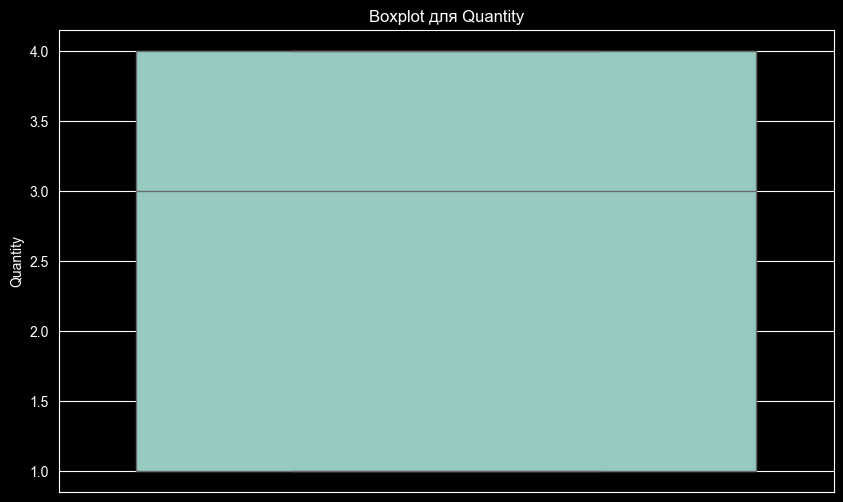

Выбросов по методу IQR: 0


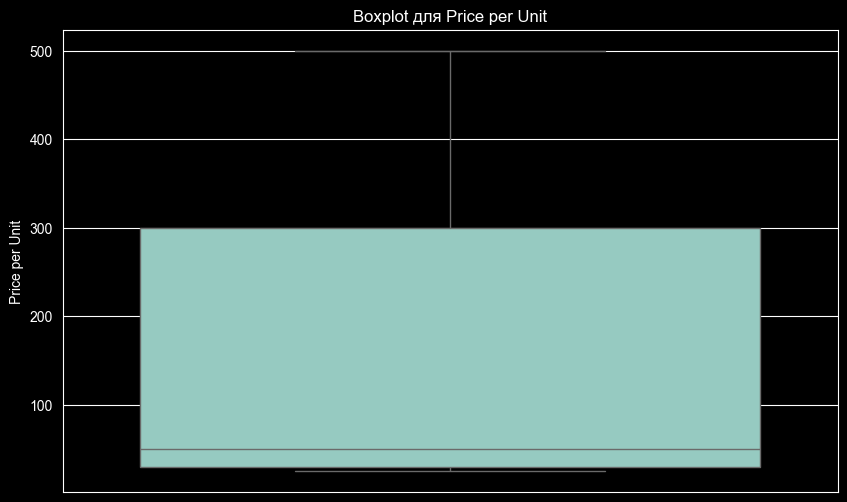

Выбросов по методу IQR: 0


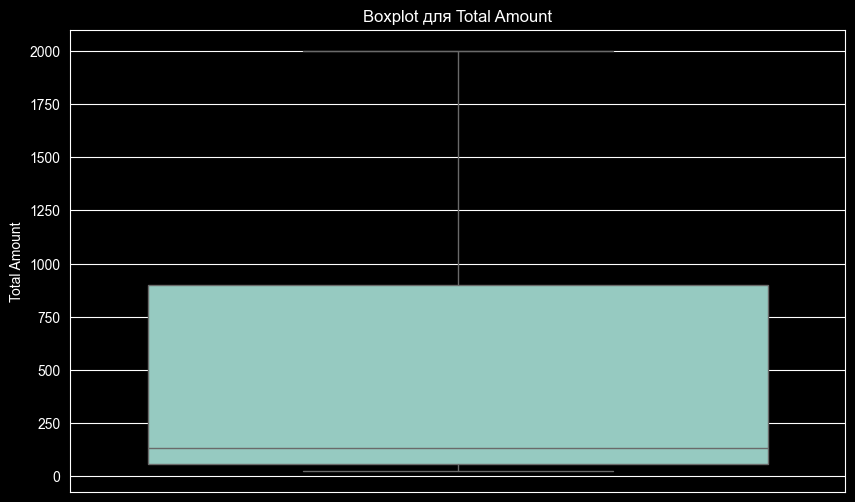

In [6]:
columns_for_outliers = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
for column in columns_for_outliers:
    Q1 = df[column].quantile(0.25) # 1 квартиль - значение, которое делит ранжированный набор данных на четыре равные части
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    #границы нормальных значений
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f'Выбросов по методу IQR: {len(outliers)}')

    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, y=column)
    plt.title(f'Boxplot для {column}')
    plt.show()

## 4. Разведочный анализ (EDA)

### 4.1. Распределение числового признака

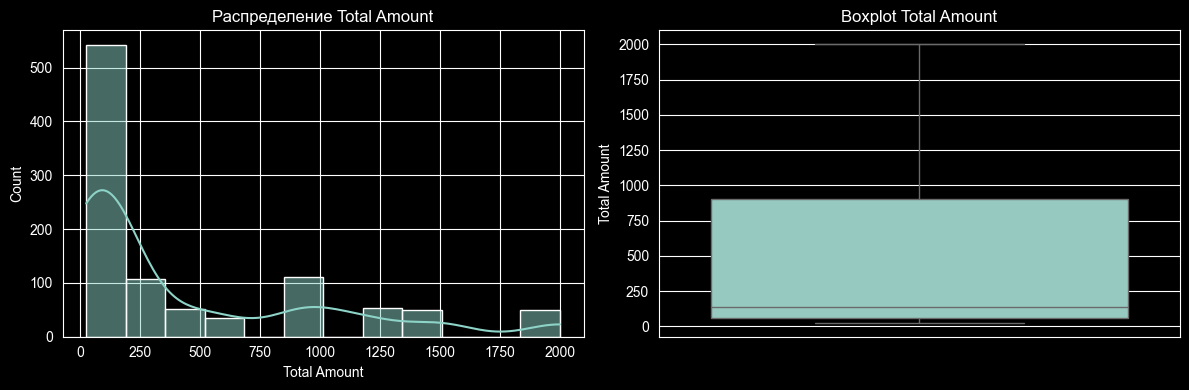

In [7]:
numeric_col = 'Total Amount'

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[numeric_col], kde=True)
plt.title(f'Распределение {numeric_col}')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[numeric_col])
plt.title(f'Boxplot {numeric_col}')
plt.tight_layout()
plt.show()

#### Что видно:
Видно резко убывающее распределение общей суммы транзакций — подавляющее большинство покупок (около 500) имеет небольшую сумму (до 250), при этом количество транзакций экспоненциально уменьшается с ростом суммы.
#### Гипотезы:
1. В магазине преобладают мелкие бытовые покупки.
2. Есть небольшая группа клиентов, генерирующая существенную выручку через редкие, но дорогие транзакции.
#### Вопросы:
1. Какие товары или категории формируют крупные чеки?
2. Стоит ли стимулировать более частые покупки с высокой суммой?

### 4.2. Анализ категориального признака

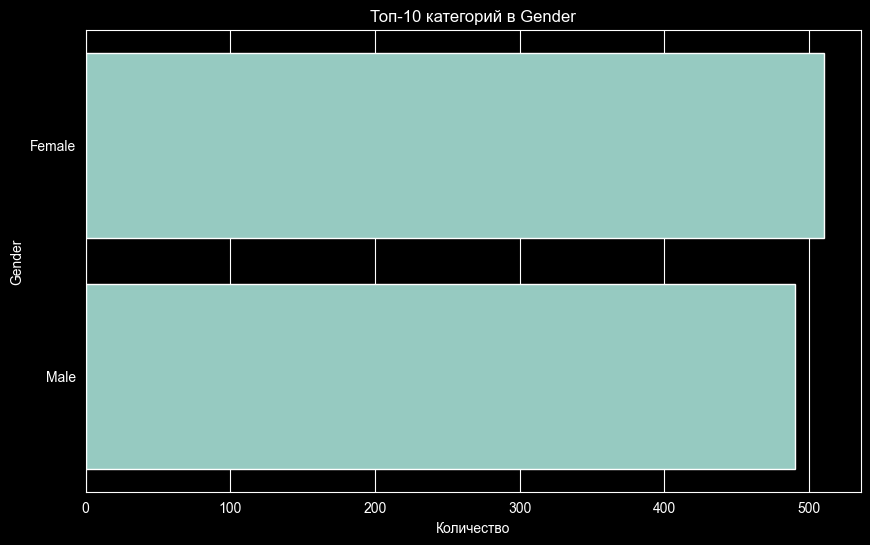

In [8]:
cat_col = 'Gender'

plt.figure(figsize=(10, 6))
top_categories = df[cat_col].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title(f'Топ-10 категорий в {cat_col}')
plt.xlabel('Количество')
plt.show()

#### Что видно:
На графике видно практически равное распределение клиентов по полу: женщины составляют 51%, мужчины — около 49%. Это указывает на сбалансированную гендерную структуру клиентской базы без выраженного перекоса в какую-либо сторону.
#### Гипотезы:
Магазин имеет универсальный ассортимент, привлекающий оба пола примерно одинаково.
#### Вопросы:
1. Есть ли различия в среднем чеке?
2. Сохраняется ли это равное соотношение во всех возрастных группах?

## 5. Выводы

Детали в файле `report/quality_report.md`